In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from sklearn.preprocessing import StandardScaler

# Path to the database folder
db_path = "../db"

def load_and_normalize_all_subjects():
    """
    Loads all voluntary_* CSV files, groups them by subject, 
    normalizes EMG channels per subject (center+left+right),
    using sklearn's StandardScaler.
    """

    # 1. Load all voluntary CSV files
    all_files = glob.glob(os.path.join(db_path, "voluntary_*.csv"))
    print(f"Total files found: {len(all_files)}")

    # Dictionary grouping files by subject
    people = {}   # people["001"] = {"center": df, "left": df, "right": df}

    for f in all_files:
        filename = os.path.basename(f)
        parts = filename.split("_")  # voluntary_001_center.csv

        subj_id = parts[1]
        position = parts[2].replace(".csv", "")

        if position not in ["center", "left", "right"]:
            continue

        df = pd.read_csv(f)

        if subj_id not in people:
            people[subj_id] = {}

        people[subj_id][position] = df

    # Output DataFrames
    list_center, list_left, list_right = [], [], []

    # 2. Normalize per subject using StandardScaler
    for subj, recs in people.items():

        # Ensure subject has all 3 recordings
        if len(recs) < 3:
            print(f"⚠️ Subject {subj} does not have all three files (center/left/right). Skipping.")
            continue

        df_c = recs["center"]
        df_l = recs["left"]
        df_r = recs["right"]

        # Identify EMG channels
        ch_cols = [c for c in df_c.columns if c.startswith("CH_")]

        # Combine recordings to compute scaler for the subject
        combined = pd.concat([df_c[ch_cols], df_l[ch_cols], df_r[ch_cols]], ignore_index=True)

        scaler = StandardScaler()
        scaler.fit(combined)  # compute μ and σ across all 3 recordings

        # Helper function to normalize and clean recordings
        def process(df_in):
            df = df_in.copy()

            # Apply scaler
            df[ch_cols] = scaler.transform(df[ch_cols])

            # Drop timestamp (index will represent time)
            if "Timestamp" in df.columns:
                df = df.drop(columns=["Timestamp"])

            df["Subject"] = subj
            return df

        # Save results
        list_center.append(process(df_c))
        list_left.append(process(df_l))
        list_right.append(process(df_r))

    # Final concatenated datasets
    final_center = pd.concat(list_center, ignore_index=True)
    final_left   = pd.concat(list_left, ignore_index=True)
    final_right  = pd.concat(list_right, ignore_index=True)

    return final_center, final_left, final_right


# ======================================================
# Load normalized datasets
# ======================================================

center_data, left_data, right_data = load_and_normalize_all_subjects()

print("\n--- Center Data ---")
print(center_data.head(), center_data.shape)

print("\n--- Left Data ---")
print(left_data.head(), left_data.shape)

print("\n--- Right Data ---")
print(right_data.head(), right_data.shape)


Total files found: 30

--- Center Data ---
       CH_1      CH_2      CH_3      CH_4      CH_5      CH_6      CH_7  \
0  0.181220  0.230497 -0.451919 -0.006888 -0.065103  0.206258 -0.095071   
1 -0.420157 -0.469287 -0.679696 -0.091495 -0.065103  0.097519 -0.095071   
2  0.381679 -0.002765  0.003634 -0.091495 -0.065103 -0.011219  0.079445   
3 -0.019239 -0.469287  0.231410  0.162325  0.001080  0.206258  0.166704   
4 -0.219698  0.230497  0.003634 -0.006888 -0.065103 -0.119958 -0.095071   

       CH_8 State Subject  
0 -0.025103  REST     001  
1  0.178345  REST     001  
2 -0.025103  REST     001  
3 -0.025103  REST     001  
4  0.178345  REST     001   (126470, 10)

--- Left Data ---
       CH_1      CH_2      CH_3      CH_4      CH_5      CH_6      CH_7  \
0  0.181220 -0.236026  0.003634 -0.091495  0.001080 -0.011219 -0.095071   
1  0.181220 -0.236026 -0.224143 -0.006888 -0.065103  0.314997  0.079445   
2  0.582138 -0.002765  0.231410 -0.006888  0.001080 -0.119958 -0.182329   
3  0.1

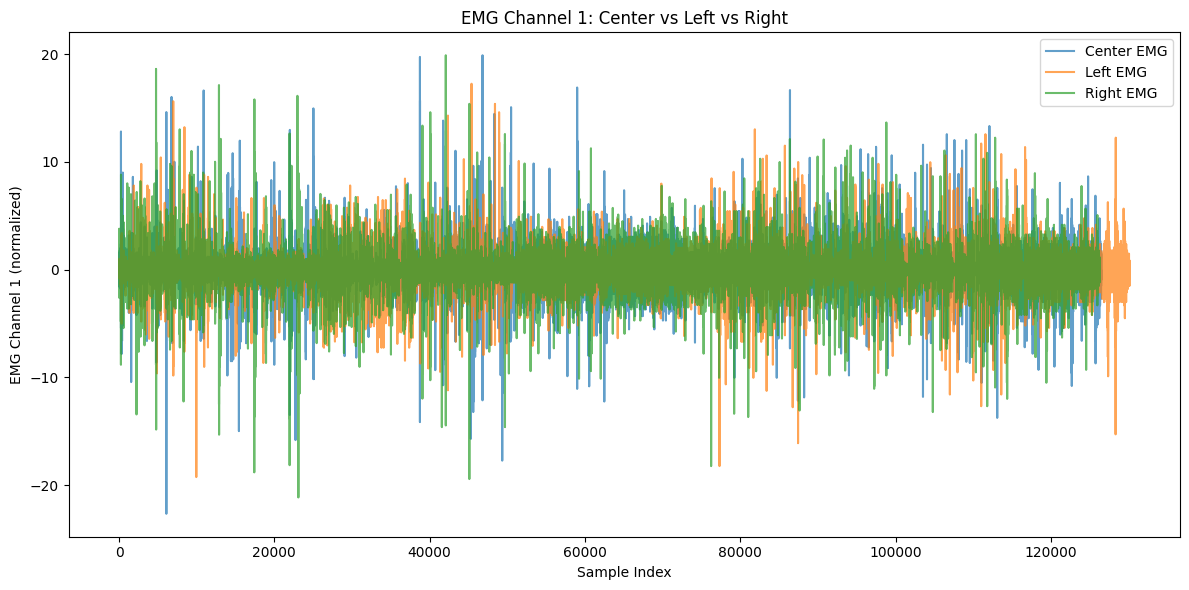

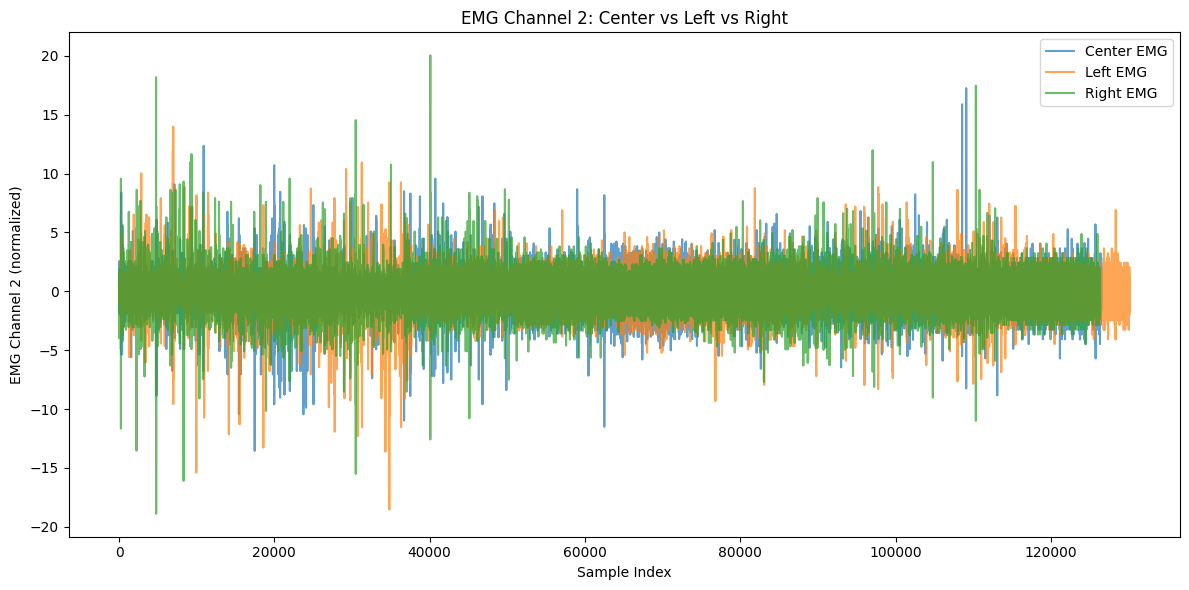

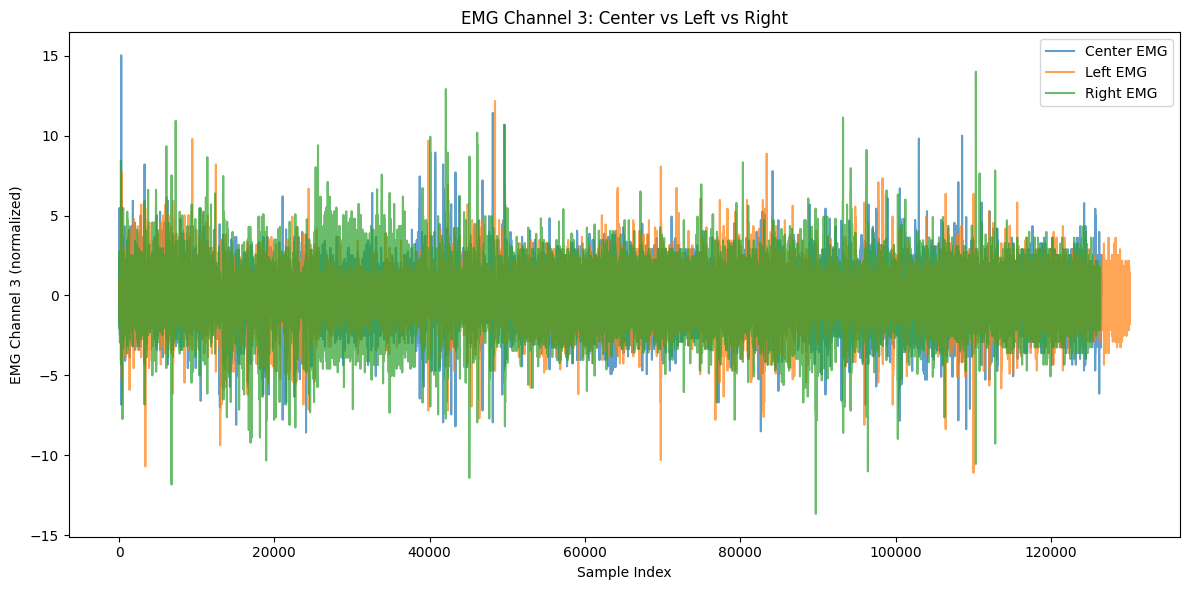

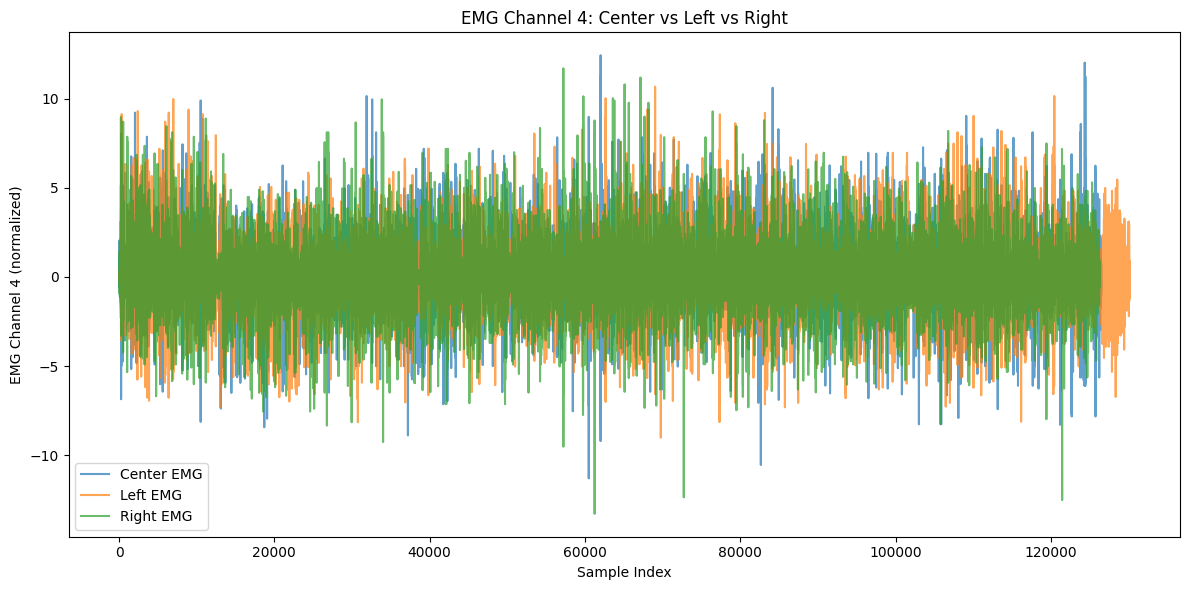

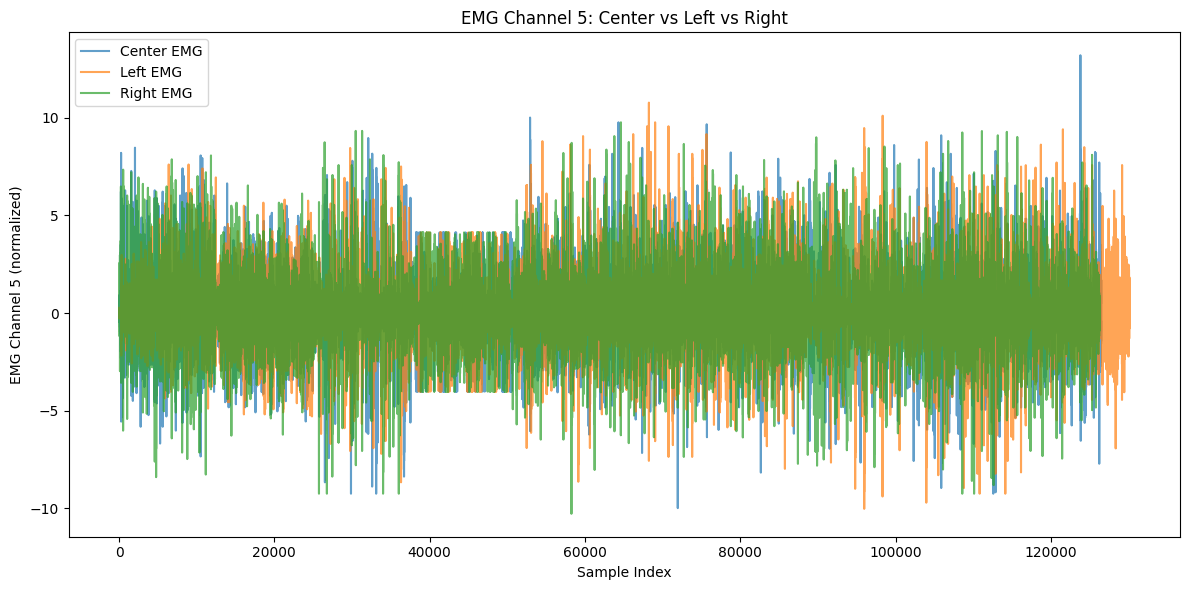

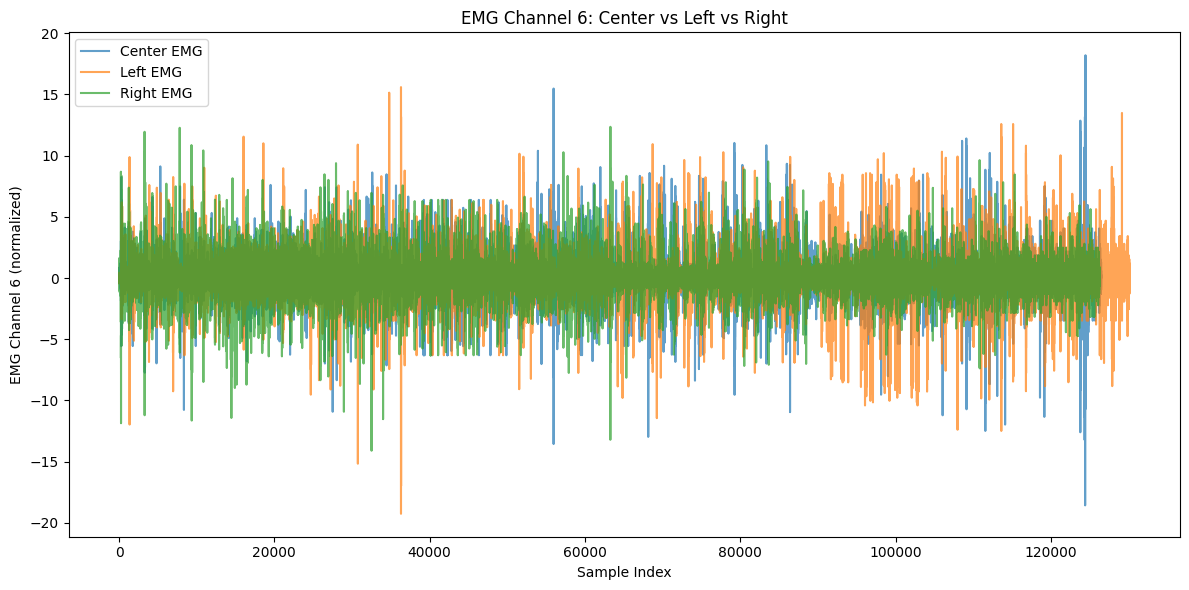

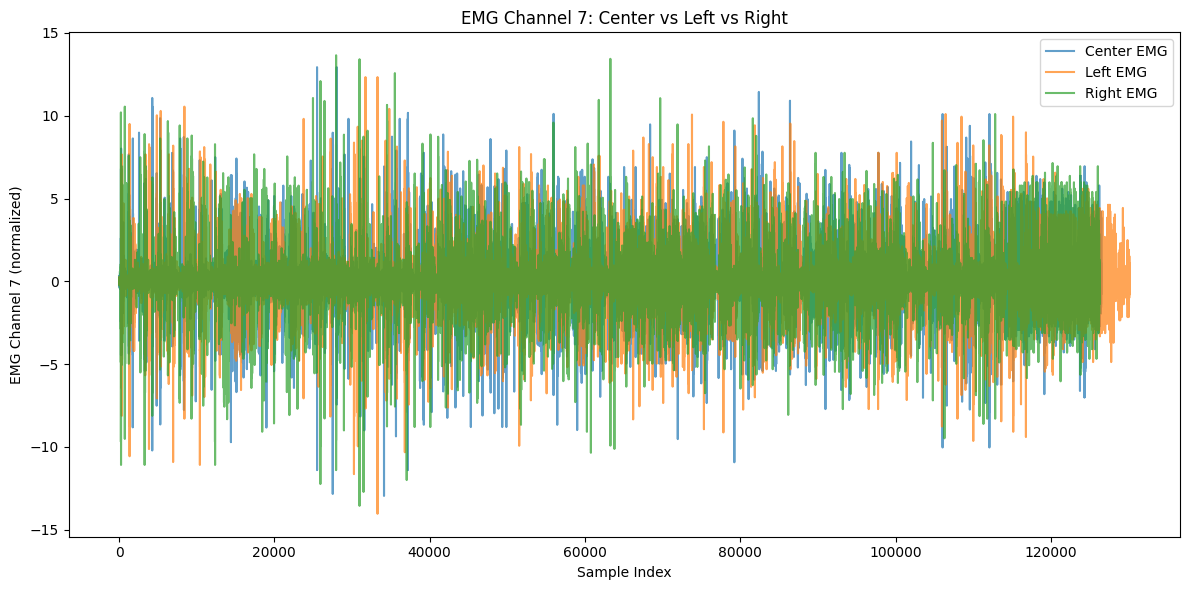

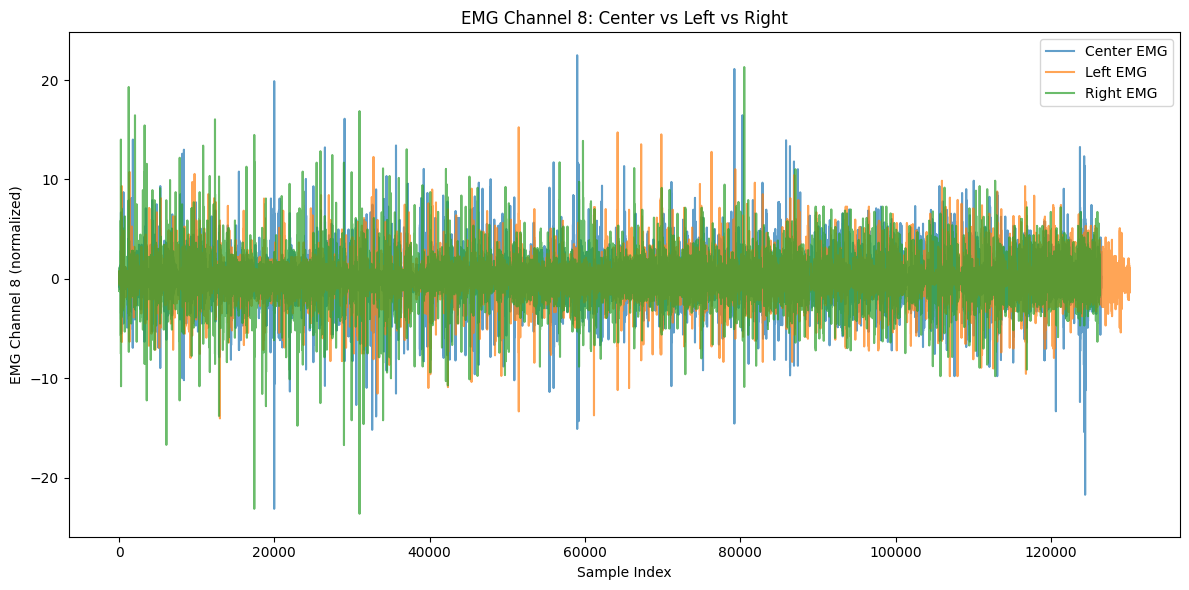

In [2]:
for i in range(1, 9):
    ch = f"CH_{i}"

    plt.figure(figsize=(12, 6))

    plt.plot(center_data.index, center_data[ch], label='Center EMG', alpha=0.7)
    plt.plot(left_data.index,   left_data[ch],   label='Left EMG', alpha=0.7)
    plt.plot(right_data.index,  right_data[ch],  label='Right EMG', alpha=0.7)

    plt.xlabel('Sample Index')
    plt.ylabel(f'EMG Channel {i} (normalized)')
    plt.title(f'EMG Channel {i}: Center vs Left vs Right')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
import pickle
import os

# ----------------------------------------------
# MATH FUNCTIONS
# ----------------------------------------------

def zero_crossings(x):
    return ((x[:-1] * x[1:]) < 0).sum()

def slope_sign_changes(x):
    return np.sum((np.diff(np.sign(np.diff(x)))) != 0)

def waveform_length(x):
    return np.sum(np.abs(np.diff(x)))

# ----------------------------------------------
# SLIDING WINDOW EXTRACTOR
# ----------------------------------------------

def extract_sliding_features(df, sensor_cols, window_size=15, step_size=1):

    df['block_id'] = (df['State'] != df['State'].shift()).cumsum()

    all_features = []
    all_labels = []

    for block_id, group in df.groupby('block_id'):

        label = group['State'].iloc[0]
        data = group[sensor_cols].values
        L = len(data)

        if L < window_size:
            continue

        for i in range(0, L - window_size + 1, step_size):
            window = data[i:i+window_size]
            row = []

            # 72 features
            for ch in range(window.shape[1]):
                x = window[:, ch]

                feats = [
                    np.sqrt(np.mean(x**2)),
                    np.mean(np.abs(x)),
                    zero_crossings(x),
                    slope_sign_changes(x),
                    waveform_length(x),
                    np.var(x),
                    np.mean(x),
                    kurtosis(x) if np.std(x) > 0 else 0,
                    skew(x) if np.std(x) > 0 else 0
                ]

                row.extend(feats)

            all_features.append(row)
            all_labels.append(label)

    # DataFrame 72 features
    feat_suffixes = ['RMS','MAV','ZC','SSC','WL','VAR','MEAN','KURT','SKEW']
    col_names = [f"{ch}_{f}" for ch in sensor_cols for f in feat_suffixes]

    X_df = pd.DataFrame(all_features, columns=col_names)
    return X_df, all_labels


# ----------------------------------------------
# MAIN
# ----------------------------------------------

# Load your 3 datasets
datasets = [center_data, left_data, right_data]
sensor_cols = [f"CH_{i}" for i in range(1,9)]

all_X = []
all_y = []

print("\nExtracting features...")
for df in datasets:
    Xf, yf = extract_sliding_features(df, sensor_cols, 15, 1)
    all_X.append(Xf)
    all_y.extend(yf)

final_X = pd.concat(all_X, ignore_index=True)
label_encoder = LabelEncoder()
final_y = label_encoder.fit_transform(all_y)

print("\nSelecting BEST 10 features...")
selector = SelectKBest(score_func=f_classif, k=10)
X10 = selector.fit_transform(final_X, final_y)
best_cols = final_X.columns[selector.get_support()]

print("\nTop 10 features:", best_cols.tolist())

# Save dataset + selected columns
os.makedirs("processed", exist_ok=True)

np.save("processed/X_10features.npy", X10)
np.save("processed/y.npy", final_y)

with open("processed/selected_features.pkl", "wb") as f:
    pickle.dump(best_cols.tolist(), f)

print("\nSaved:")
print("  processed/X_10features.npy")
print("  processed/y.npy")
print("  processed/selected_features.pkl")


Extracting features...

Selecting BEST 10 features...

Top 10 features: ['CH_5_RMS', 'CH_5_MAV', 'CH_5_WL', 'CH_6_MAV', 'CH_6_WL', 'CH_7_RMS', 'CH_7_MAV', 'CH_7_WL', 'CH_8_MAV', 'CH_8_WL']

Saved:
  processed/X_10features.npy
  processed/y.npy
  processed/selected_features.pkl


In [4]:
for i, cls in enumerate(label_encoder.classes_):
    print(i, cls)

0 LATERAL
1 OPEN
2 POINTER
3 POWER
4 REST
5 TRIPOD


In [5]:
final_X

,CH_1_RMS,CH_1_MAV,CH_1_ZC,CH_1_SSC,CH_1_WL,CH_1_VAR,CH_1_MEAN,CH_1_KURT,CH_1_SKEW,CH_2_RMS,...,CH_7_SKEW,CH_8_RMS,CH_8_MAV,CH_8_ZC,CH_8_SSC,CH_8_WL,CH_8_VAR,CH_8_MEAN,CH_8_KURT,CH_8_SKEW
0,0.390720,0.273692,7,8,7.216525,0.148948,0.060944,0.399125,1.049278,0.567210,...,0.100711,0.317310,0.232248,11,12,6.306896,0.100443,0.015587,0.235660,-0.651817
1,0.392034,0.276257,6,8,6.615147,0.152520,0.034216,0.557034,1.191585,0.592529,...,0.089919,0.317310,0.232248,11,12,6.306896,0.100443,0.015587,0.235660,-0.651817
2,0.392034,0.276257,5,8,6.013770,0.152520,0.034216,0.557034,1.191585,0.592529,...,-0.289225,0.317310,0.232248,11,12,6.306896,0.100443,0.015587,0.235660,-0.651817
3,0.383662,0.265458,4,9,5.813311,0.147162,-0.005875,1.351364,1.503049,0.604791,...,-0.131618,0.317310,0.232248,12,12,6.510345,0.100443,0.015587,0.235660,-0.651817
4,0.398674,0.292186,4,9,5.813311,0.157878,-0.032603,1.230350,1.479195,0.604506,...,0.045179,0.322686,0.245811,11,11,6.510345,0.104122,0.002024,-0.065196,-0.520141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361821,0.650448,0.481092,7,9,11.971658,0.415630,0.086332,-0.218193,-0.123263,1.129587,...,-0.114696,1.122628,0.919667,4,6,14.696628,1.254308,0.077364,-0.811829,0.322591
361822,0.665079,0.501045,8,9,12.570241,0.437924,0.066379,-0.428926,-0.091824,1.115445,...,0.098361,1.095890,0.868811,5,6,14.463349,1.176912,0.155124,-0.659115,0.198700
361823,0.707158,0.560903,7,8,11.672367,0.500030,0.006521,-0.809500,-0.007728,1.100715,...,0.098361,1.154492,0.946571,6,7,15.863028,1.326868,0.077364,-0.893649,0.197931
361824,0.645878,0.505496,6,8,10.774493,0.408464,-0.093243,-0.540628,0.055867,0.968534,...,0.098361,1.226281,1.051235,6,8,18.195826,1.469084,0.186228,-1.175135,0.032316


In [6]:
X_selected = np.load("processed/X_10features.npy")
y = np.load("processed/y.npy")

with open("processed/selected_features.pkl", "rb") as f:
    cols = pickle.load(f)

print("X_selected shape:", X_selected.shape)
print("y shape:", y.shape)
print("Selected columns:", cols)

X_selected shape: (361826, 10)
y shape: (361826,)
Selected columns: ['CH_5_RMS', 'CH_5_MAV', 'CH_5_WL', 'CH_6_MAV', 'CH_6_WL', 'CH_7_RMS', 'CH_7_MAV', 'CH_7_WL', 'CH_8_MAV', 'CH_8_WL']


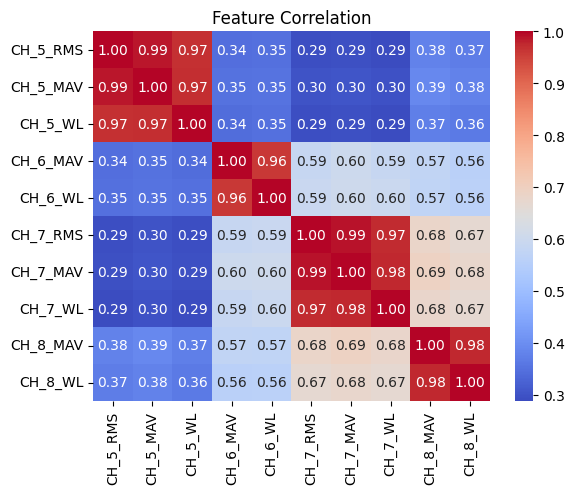

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd.DataFrame(X_selected, columns=cols).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ----------- USE AS 10 FEATURES SELECIONADAS -----------
X = X_selected              # agora é (N amostras, 10 features)
y = final_y                 # rótulos
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

average=np.array([0])
preci=np.array([0])
senci=np.array([0])
bst_est=[]

kf = KFold(n_splits=5, shuffle=True, random_state=7)

def training_and_testing(estimator, param_grid, X_train, y_train, X_test, y_test):
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=kf,
        scoring='accuracy',
        verbose=2
    )

    # Perform the grid search
    grid_search.fit(X_train, y_train)

    # Best parameters and best score
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    sensitivity = recall_score(y_test, y_pred, average='weighted')

    print(f"Final Test Accuracy: {accuracy:.2f}")
    print(f"Final Test Precision: {precision:.2f}")
    print(f"Final Test Sensitivity (Recall): {sensitivity:.2f}")

    # Confusion matrix
    print("\nFinal Confusion Matrix (on test data):")
    mat_con = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=mat_con)
    disp.plot()
    plt.show()

    return accuracy, precision, sensitivity, grid_search


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   1.9s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   1.9s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   2.0s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   1.8s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   1.8s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   1.2s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   1.3s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   1.2s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   1.2s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   1.3s
[CV] END ....................metric=minkowski, n_neighbors=6; total time=   1.4s
[CV] END ....................metric=minkowski, n

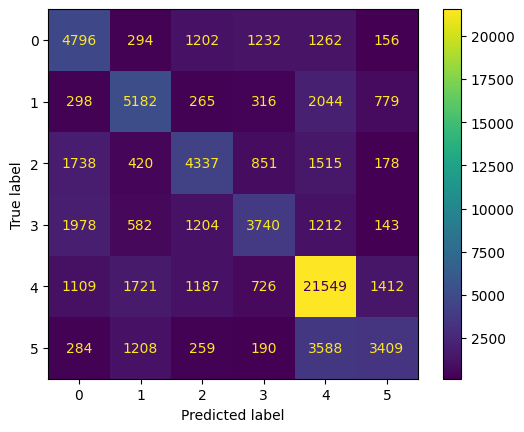

Accuracy:  0.5943813393029876
Precision:  0.588637681377417
Sensitivity:  0.5943813393029876
✔ Saved best KNN model → db/knn_model_10_features.joblib


In [9]:
from sklearn.neighbors import KNeighborsClassifier
import joblib
# Define the model and parameters to tune
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [2, 4, 6, 8],  # You can extend this list based on your dataset
    #'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'chebyshev', 'euclidean', 'manhattan']
}

accuracy, precision, sensitivity, grid_search = training_and_testing(knn, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST KNN MODEL ---
best_knn = grid_search.best_estimator_
joblib.dump(best_knn, "db/knn_model_10_features.joblib")
print("✔ Saved best KNN model → db/knn_model_10_features.joblib")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ....................var_smoothing=0.657933224657568; total time=   0.0s
[CV] END ....................var_smoothing=0.6

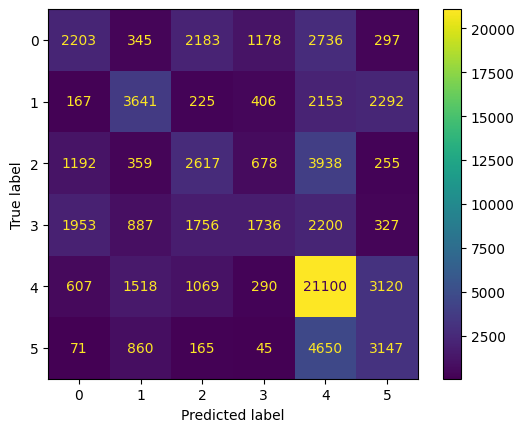

Accuracy:  0.47596937788464194
Precision:  0.45334755398747606
Sensitivity:  0.47596937788464194
✔ Saved best GaussianNB model → db/gnb_model_10_features.joblib


In [10]:
from sklearn.naive_bayes import GaussianNB
import joblib
# Define the model and parameters to tune
gnb = GaussianNB()
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

accuracy, precision, sensitivity, grid_search = training_and_testing(gnb, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST GAUSSIANNB MODEL ---
best_gnb = grid_search.best_estimator_
joblib.dump(best_gnb, "db/gnb_model_10_features.joblib")
print("✔ Saved best GaussianNB model → db/gnb_model_10_features.joblib")

In [11]:
# from sklearn.linear_model import LogisticRegression
# # Define the model and parameters to tune
# log_reg = LogisticRegression(max_iter=10000)  # Increasing max_iter for convergence with larger datasets or more complex models
# param_grid = {
#     'C': np.logspace(-4, 4, 20),  # Explore a range of regularization strengths
#     'penalty': ['l1', 'l2']#,  # 'l1', 'l2', 'elasticnet' might be options, depending on the solver
#     #'solver': ['lbfgs', 'liblinear']  # Suitable solvers for small to medium datasets
# }

# accuracy, precision, sensitivity, grid_search = training_and_testing(log_reg, param_grid, X_train, y_train, X_test, y_test)
# print("Accuracy: ", accuracy)
# print("Precision: ", precision)
# print("Sensitivity: ", sensitivity)
# average = np.vstack((average,accuracy))
# preci=np.vstack((preci,precision))
# senci=np.vstack((senci,sensitivity))
# bst_est.append(grid_search.best_params_) 

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   1.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   1.2s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=6; total time=   1.2s
[CV] END max_depth=5, min_samples_le

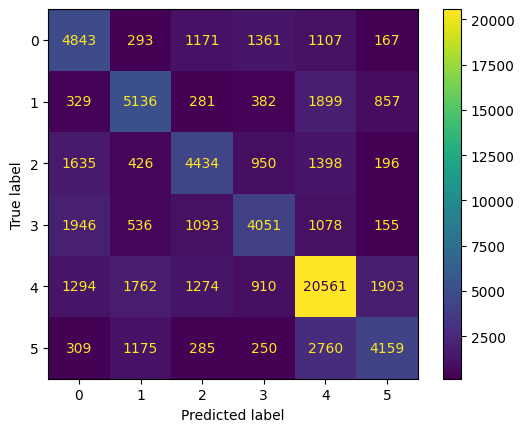

Accuracy:  0.5967443274465909
Precision:  0.5953459216769798
Sensitivity:  0.5967443274465909
✔ Saved best Decision Tree model → db/decision_tree_10_features_model.joblib


In [12]:
from sklearn.tree import DecisionTreeClassifier
import joblib
# Define the model and parameters to tune
decision_tree = DecisionTreeClassifier()
param_grid = {
    'max_depth': [5, 10, 15, 20, 25, 30],  # None means no limit
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [2, 4, 6, 8]
}

accuracy, precision, sensitivity, grid_search = training_and_testing(decision_tree, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST DECISION TREE MODEL ---
best_dt = grid_search.best_estimator_
joblib.dump(best_dt, "db/decision_tree_10_features_model.joblib")
print("✔ Saved best Decision Tree model → db/decision_tree_10_features_model.joblib")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  26.9s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  26.3s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  26.4s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  25.8s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  25.8s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  53.2s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  52.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  51.8s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  52.7s
[CV] END max_depth=5, min_samples_lea

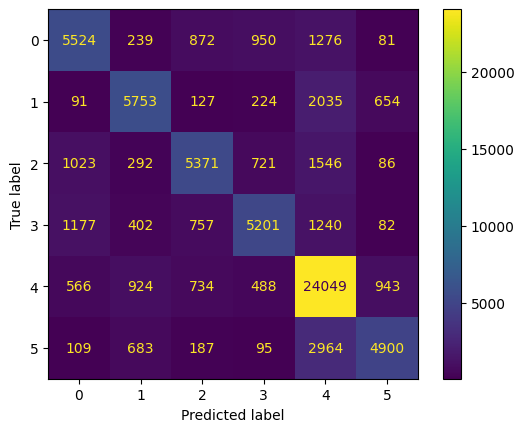

Accuracy:  0.7019594837354559
Precision:  0.6996138886044898
Sensitivity:  0.7019594837354559
✔ Saved best Random Forest model → db/random_forest_model_10_features.joblib


In [13]:
from sklearn.ensemble import RandomForestClassifier
import joblib
# Define the model and parameters to tune
random_forest = RandomForestClassifier()
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [5, 10, 15, 20],  # Maximum depth of the tree
    'min_samples_split': [2, 4, 6, 8],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8]  # Minimum number of samples required at each leaf node
}

accuracy, precision, sensitivity, grid_search = training_and_testing(random_forest, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST RANDOM FOREST MODEL ---
best_rf = grid_search.best_estimator_
joblib.dump(best_rf, "db/random_forest_model_10_features.joblib")
print("✔ Saved best Random Forest model → db/random_forest_model_10_features.joblib")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV # Assuming you use KFold
def training_and_testing_svm(estimator, param_grid, X_train, y_train, X_test, y_test):
    grid_search = RandomizedSearchCV(estimator=estimator, param_distributions=param_grid, cv=kf, scoring='accuracy', verbose=3, n_iter=50)  # n_iter can be adjusted based on the number of combinations you want to try

    # Perform the grid search
    grid_search.fit(X_train, y_train)

    # Best parameters and best score
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Calculate and print all final metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    sensitivity = recall_score(y_test, y_pred, average='weighted') # Sensitivity is the same as recall

    print(f"Final Test Accuracy: {accuracy:.2f}")
    print(f"Final Test Precision: {precision:.2f}")
    print(f"Final Test Sensitivity (Recall): {sensitivity:.2f}")

    # Display the final confusion matrix
    print("\nFinal Confusion Matrix (on test data):")
    mat_con = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=mat_con)
    disp.plot()
    plt.show()
    return accuracy, precision, sensitivity, grid_search

from sklearn.svm import SVC
from sklearn.datasets import make_classification # Import make_classification
from sklearn.model_selection import train_test_split # Import train_test_split

from sklearn.svm import SVC
# Define the model and parameters to tune
svm = SVC()
param_grid = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 1, 0.1, 0.01]},
    #{'kernel': ['linear'], 'C': [0.1, 1, 10, 100]}
]

accuracy, precision, sensitivity, grid_search = training_and_testing_svm(svm, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=50. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.514 total time=49.2min
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.513 total time=51.1min


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import joblib

lda = LinearDiscriminantAnalysis()
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]
}

accuracy, precision, sensitivity, grid_search = training_and_testing(lda, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST LDA MODEL ---
best_lda = grid_search.best_estimator_
joblib.dump(best_lda, "db/lda_model_10_features.joblib")
print("✔ Saved best LDA model → db/lda_model_10_features.joblib")

In [ ]:
from sklearn.neural_network import MLPClassifier
import joblib

mlp = MLPClassifier(max_iter=1000)  # Increased max_iter for better convergence
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
              'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
              'activation': ['tanh  ', 'relu'],
              'solver': ['adam', 'sgd']}

accuracy, precision, sensitivity, grid_search = training_and_testing(mlp, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST MLP MODEL ---
best_mlp = grid_search.best_estimator_
joblib.dump(best_mlp, "db/mlp_model_10_features.joblib")
print("✔ Saved best MLP model → db/mlp_model_10_features.joblib")

In [ ]:
# prompt: take  average preci and sensci  and consider this, rows are porcentages so must be *100 and it must be first column value +/- second column value, storage them as csv
import pandas as pd
def create_df(average, preci, senci, bst_est):
    # Convert numpy arrays to DataFrames
    average_df = pd.DataFrame(average, columns=['Accuracy'])
    preci_df = pd.DataFrame(preci, columns=['Precision'])
    senci_df = pd.DataFrame(senci, columns=['Sensitivity'])

    # Multiply the columns by 100 for percentage
    average_df[['Accuracy']] *= 100
    preci_df[['Precision']] *= 100
    senci_df[['Sensitivity']] *= 100

    # Combine mean and std columns into a single string format for each metric
    average_df['Accuracy'] = average_df['Accuracy'].round(2).astype(str) 
    preci_df['Precision'] = preci_df['Precision'].round(2).astype(str)
    senci_df['Sensitivity'] = senci_df['Sensitivity'].round(2).astype(str)

    results_df = pd.DataFrame({
    'Model': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'SVM', 'LDA', 'MLP'],
    'Accuracy': average_df['Accuracy'].iloc[1:].values,
    'Precision': preci_df['Precision'].iloc[1:].values,
    'Sensitivity': senci_df['Sensitivity'].iloc[1:].values,
    'Best Estimator Params': bst_est
    })
    return results_df

results_df = create_df(average, preci, senci, bst_est)
# Save the results to a CSV file
results_df.to_csv('model_performance_summary_force_hybrid.csv', index=False)

print("\nModel Performance Summary:")
results_df